# 📱 Social Media Engagement Prediction — K-Nearest Neighbors (KNN)

**Dataset:** `social_media_engagement_dataset.csv`  
**Algorithm:** K-Nearest Neighbors  
**Task:** Classify posts into engagement tiers (High / Medium / Low)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

print("All libraries imported successfully ✓")

All libraries imported successfully ✓


## 2. Load & Explore the Dataset

In [2]:
df = pd.read_csv('/content/social_media_engagement_dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (5000, 20)


,Post_ID,Timestamp,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified
0,POST_04552,2024-01-01 01:42:00,Instagram,Carousel,Business,8287,247,51,29502,20,223080,3.85,1,Monday,16,985,Positive,Macro,True,False
1,POST_02171,2024-01-01 05:05:00,LinkedIn,Document,Health,1711,27,247,24538,139,312647,0.63,5,Monday,9,627,Negative,Macro,False,True
2,POST_00210,2024-01-01 09:18:00,Instagram,Carousel,Food,1527,191,7,5460,359,220737,0.78,9,Monday,27,79,Positive,Macro,True,True
3,POST_01548,2024-01-01 10:58:00,Facebook,Video,Sports,535,178,433,68246,740,428935,0.27,10,Monday,17,554,Neutral,Macro,True,False
4,POST_01350,2024-01-01 13:12:00,Instagram,Photo,Fitness,9706,35,118,25782,611,64384,15.31,13,Monday,5,1136,Positive,Mid-tier,True,False


In [3]:
print("Columns:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Columns:
 ['Post_ID', 'Timestamp', 'Platform', 'Content_Type', 'Category', 'Likes', 'Comments', 'Shares', 'Views', 'Saves', 'Follower_Count', 'Engagement_Rate', 'Hour_of_Day', 'Day_of_Week', 'Hashtag_Count', 'Content_Length', 'Sentiment', 'Influencer_Tier', 'Has_Media', 'Is_Verified']

Data types:
 Post_ID             object
Timestamp           object
Platform            object
Content_Type        object
Category            object
Likes                int64
Comments             int64
Shares               int64
Views                int64
Saves                int64
Follower_Count       int64
Engagement_Rate    float64
Hour_of_Day          int64
Day_of_Week         object
Hashtag_Count        int64
Content_Length       int64
Sentiment           object
Influencer_Tier     object
Has_Media             bool
Is_Verified           bool
dtype: object

Missing values:
 Post_ID            0
Timestamp          0
Platform           0
Content_Type       0
Category           0
Likes              0
Co

,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Hashtag_Count,Content_Length
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7536.838400,339.898800,835.233400,110968.397000,753.150600,249959.204000,11.960148,11.562600,14.755800,754.508400
std,10169.129568,399.813585,1013.769853,181287.350216,932.653475,144592.908235,71.462053,6.946577,8.666117,576.334039
min,18.000000,1.000000,2.000000,527.000000,5.000000,543.000000,0.050000,0.000000,0.000000,15.000000
25%,1707.750000,96.000000,177.000000,18506.750000,200.000000,124560.250000,1.030000,5.000000,7.000000,280.000000
50%,4073.500000,212.000000,427.500000,40663.500000,424.000000,248930.500000,2.300000,12.000000,15.000000,549.000000
75%,7783.000000,377.000000,1111.500000,84226.750000,805.000000,374697.500000,6.245000,18.000000,22.000000,1226.250000
max,49949.000000,1999.000000,4997.000000,999256.000000,4985.000000,499815.000000,3510.460000,23.000000,29.000000,1999.000000


## 3. Exploratory Data Analysis

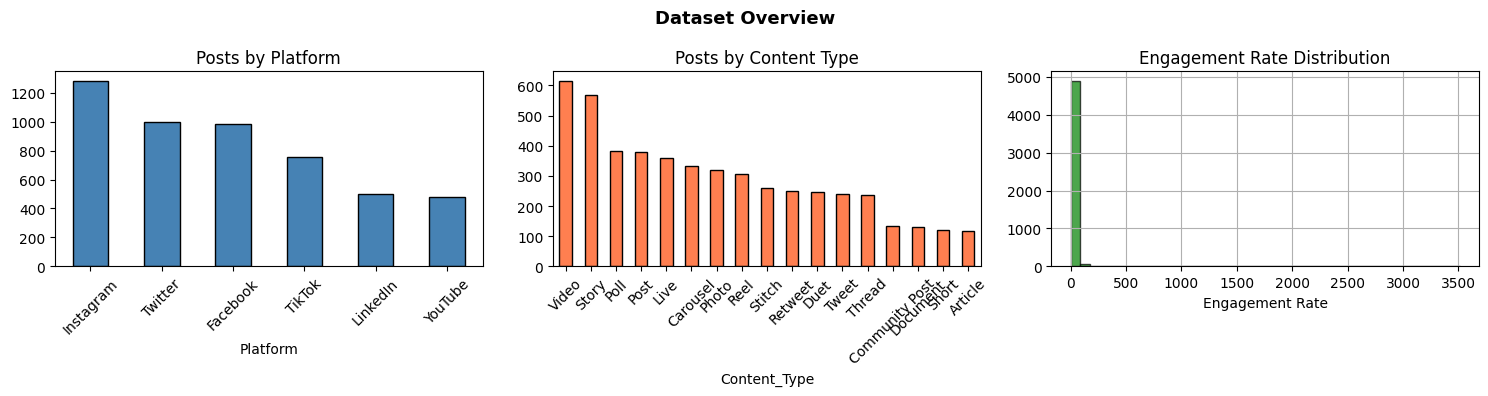

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Platform'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Posts by Platform')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

df['Content_Type'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Posts by Content Type')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

df['Engagement_Rate'].hist(bins=40, ax=axes[2], color='green', edgecolor='black', alpha=0.7)
axes[2].set_title('Engagement Rate Distribution')
axes[2].set_xlabel('Engagement Rate')

plt.suptitle('Dataset Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

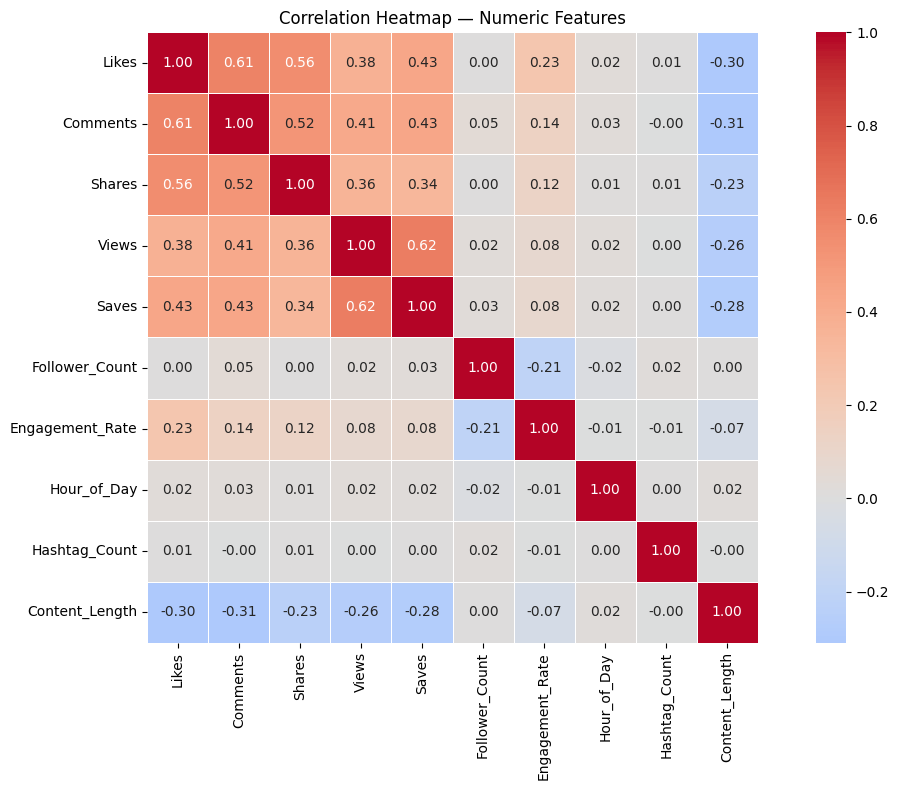

In [5]:
# Correlation heatmap for numeric features
num_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

## 4. Feature Engineering — Create Engagement Target Label

Engagement Label distribution:
Engagement_Label
Medium    1690
Low       1661
High      1649
Name: count, dtype: int64


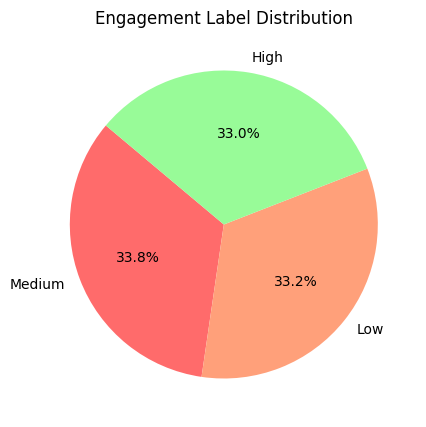

In [6]:
# Create 3-class engagement label based on Engagement_Rate percentiles
low_t  = df['Engagement_Rate'].quantile(0.33)
high_t = df['Engagement_Rate'].quantile(0.67)

def label_engagement(er):
    if er <= low_t:   return 'Low'
    elif er <= high_t: return 'Medium'
    else:              return 'High'

df['Engagement_Label'] = df['Engagement_Rate'].apply(label_engagement)
print("Engagement Label distribution:")
print(df['Engagement_Label'].value_counts())

df['Engagement_Label'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=140,
    colors=['#FF6B6B','#FFA07A','#98FB98'], figsize=(5,5))
plt.title('Engagement Label Distribution')
plt.ylabel('')
plt.show()

In [7]:
print(df['Engagement_Label'].value_counts(normalize=True)*100)

Engagement_Label
Medium    33.80
Low       33.22
High      32.98
Name: proportion, dtype: float64


## 5. Preprocessing

In [17]:
# Select features
features = ['Likes','Comments','Shares','Views','Saves',
            'Follower_Count','Hour_of_Day','Day_of_Week',
            'Hashtag_Count','Content_Length','Has_Media','Is_Verified']

# Encode boolean columns
df['Has_Media']   = df['Has_Media'].astype(int)
df['Is_Verified'] = df['Is_Verified'].astype(int)

X = df[features].copy()
y = df['Engagement_Label']

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Classes:", le.classes_)
print("Feature matrix shape:", X.shape)

Classes: ['High' 'Low' 'Medium']
Feature matrix shape: (5000, 12)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

# One-hot encode 'Day_of_Week' for X_train and X_test
# pd.get_dummies handles categorical columns and converts them to numerical
X_encoded = pd.get_dummies(X, columns=['Day_of_Week'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train size: {X_train_sc.shape}  |  Test size: {X_test_sc.shape}")

Train size: (4000, 17)  |  Test size: (1000, 17)


## 6. Find Optimal K

In [20]:
k_range = range(1, 31)
cv_mean_scores = []

for k in k_range:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean',
        weights='distance'
    )

    scores = cross_val_score(
        knn,
        X_train_sc,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    cv_mean_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_mean_scores)]

print(f"Best K = {best_k}")
print(f"CV Accuracy = {max(cv_mean_scores):.4f}")

Best K = 19
CV Accuracy = 0.6593


## 7. Train Final KNN Model

In [21]:
knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean',weights='distance')
knn.fit(X_train_sc, y_train)
y_pred = knn.predict(X_test_sc)

acc = accuracy_score(y_test, y_pred)
print(f"Final Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Final Accuracy: 0.6940 (69.40%)

Classification Report:
              precision    recall  f1-score   support

        High       0.86      0.83      0.84       330
         Low       0.66      0.74      0.70       332
      Medium       0.57      0.51      0.54       338

    accuracy                           0.69      1000
   macro avg       0.69      0.70      0.69      1000
weighted avg       0.69      0.69      0.69      1000



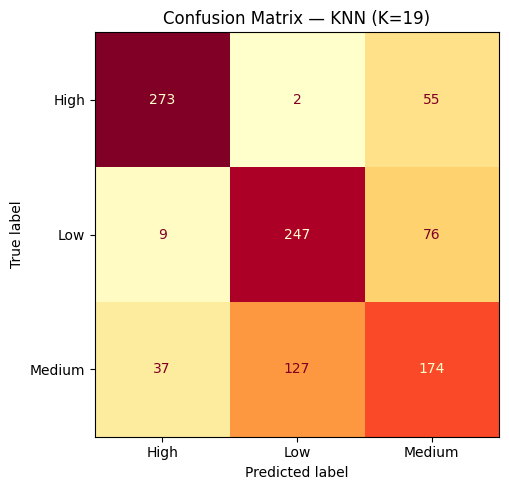

In [22]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='YlOrRd', colorbar=False)
ax.set_title(f'Confusion Matrix — KNN (K={best_k})')
plt.tight_layout()
plt.show()

## 8. Cross-Validation

5-Fold Cross-Validation Scores: [0.6525 0.6562 0.665  0.6775 0.645 ]
Mean Accuracy : 0.6593 ± 0.0112


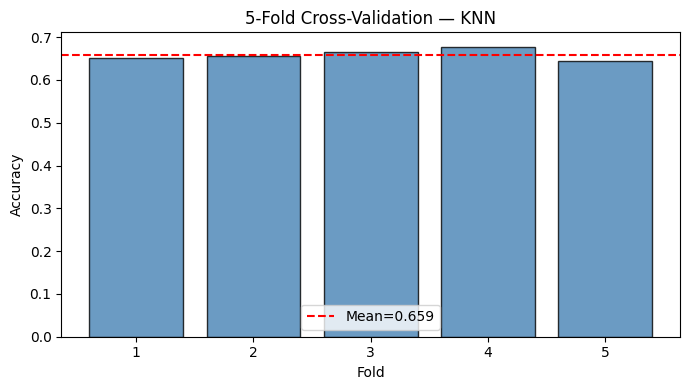

In [23]:
cv_scores = cross_val_score(
    knn,
    X_train_sc,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("5-Fold Cross-Validation Scores:", np.round(cv_scores, 4))
print(f"Mean Accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black', alpha=0.8)
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean={cv_scores.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation — KNN')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Feature Importance (via Permutation)
*(We approximate importance by measuring accuracy drop when each feature is shuffled)*

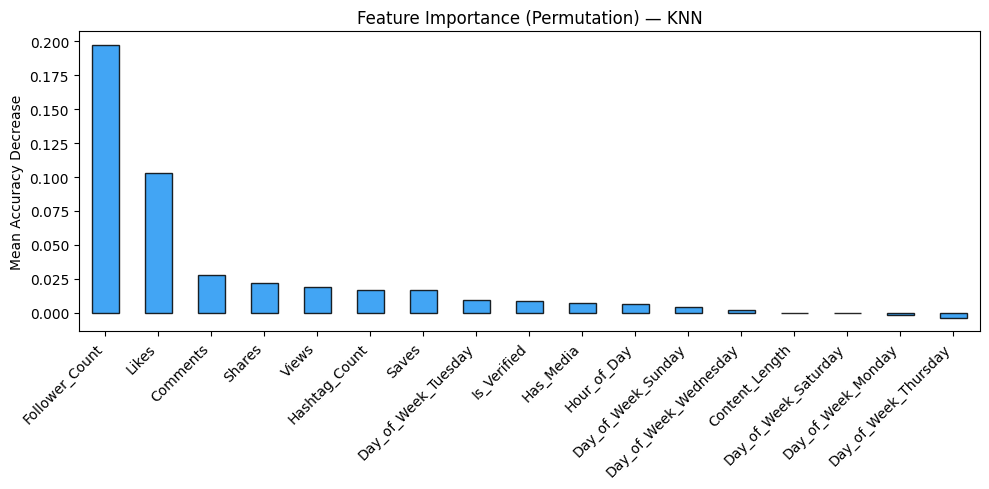

In [24]:
from sklearn.inspection import permutation_importance

result = permutation_importance(knn, X_test_sc, y_test, n_repeats=10, random_state=42)
feat_imp = pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='#2196F3', edgecolor='black', alpha=0.85)
plt.title('Feature Importance (Permutation) — KNN')
plt.ylabel('Mean Accuracy Decrease')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Summary

| Metric | Value |
|--------|-------|
| Algorithm | K-Nearest Neighbors |
| Best K | (determined above) |
| Distance Metric | Euclidean |
| Scaling | StandardScaler |
| Train/Test split | 80% / 20% |
| CV Folds | 5 |

> **KNN** classifies a new point by looking at the K closest training examples. Feature scaling is essential because KNN is distance-based — without scaling, large-range features like *Views* would dominate distance calculations.